In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All Libraries imported successfully")

All Libraries imported successfully


In [2]:
df = sns.load_dataset('titanic')
print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
df.head()
#df.shape
#df.columns
#df.info()
#df.describe()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

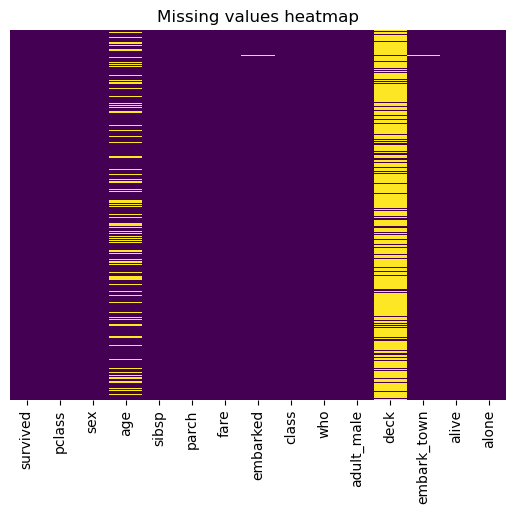

In [5]:
plt.Figure(figsize=(10,6))
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.title("Missing values heatmap")
plt.show()

In [6]:
df['age']= df['age'].fillna(df['age'].median())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
df=df.drop(columns=['deck','embark_town','alive','who','adult_male', 'alone'])
print(df.isnull().sum())



survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
class       0
dtype: int64


## Exploratory Data Analysis

##### Chart 1 — How many survived?

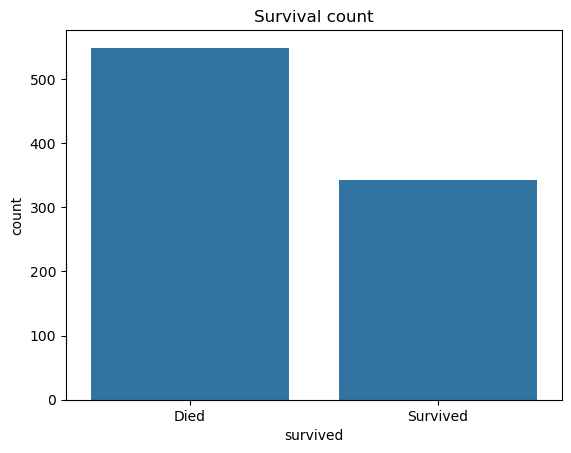

survived
0    549
1    342
Name: count, dtype: int64
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [7]:
plt.Figure(figsize=(6,4))
sns.countplot(x='survived',data=df)
plt.title("Survival count")
plt.xticks([0,1],['Died','Survived'])
plt.savefig('images/survival_count.png', bbox_inches='tight')
plt.show()
print(df['survived'].value_counts())
print(df['survived'].value_counts(normalize=True)*100)

#### Chart 2 — Survival by Gender

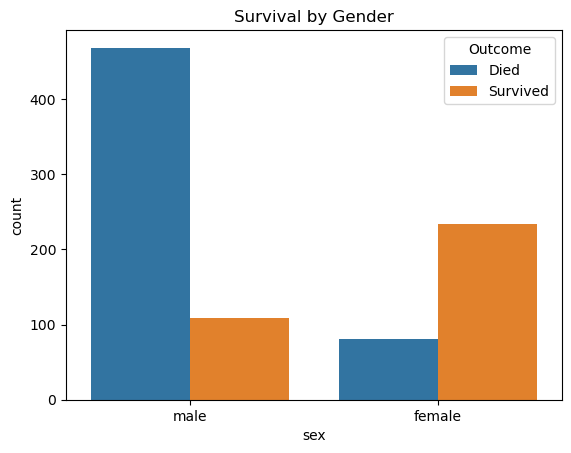

sex
male      577
female    314
Name: count, dtype: int64
sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64
        Survived  Total  Survival Rate %
sex                                     
female       233    314             74.2
male         109    577             18.9


In [8]:
plt.Figure(figsize=(6,4))
sns.countplot(x='sex',data=df,hue='survived')
plt.title("Survival by Gender")
plt.legend(labels=['Died','Survived'],title='Outcome')
plt.savefig('images/survival_by_gender.png', bbox_inches='tight')
plt.show()

print(df['sex'].value_counts())
print(df['sex'].value_counts(normalize=True)*100)

# percentage breakdown
total=df.groupby('sex')['survived'].agg(['sum','count'])
total['percentage'] = (total['sum']/total['count']*100).round(1)
total.columns=['Survived','Total','Survival Rate %']
print(total)


#### Chart 3 — Survival by Passenger Class

<function matplotlib.pyplot.show(close=None, block=None)>

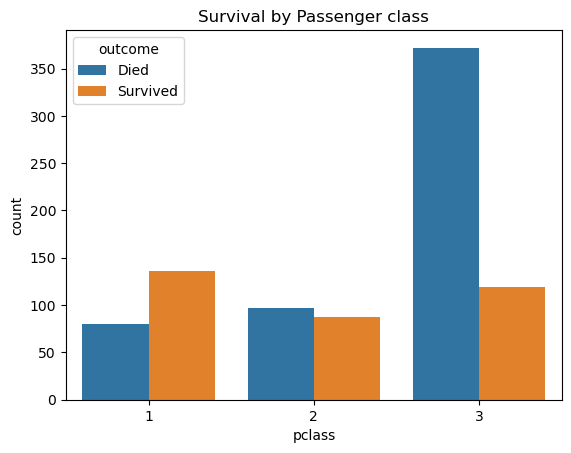

In [9]:
plt.Figure(figsize=(6,4))
sns.countplot(x='pclass',hue='survived',data=df)
plt.title('Survival by Passenger class')
plt.legend(labels=['Died','Survived'],title='outcome')
plt.savefig('images/survival_by_class.png', bbox_inches='tight')
plt.show


#### Chart 4 — Age Distribution


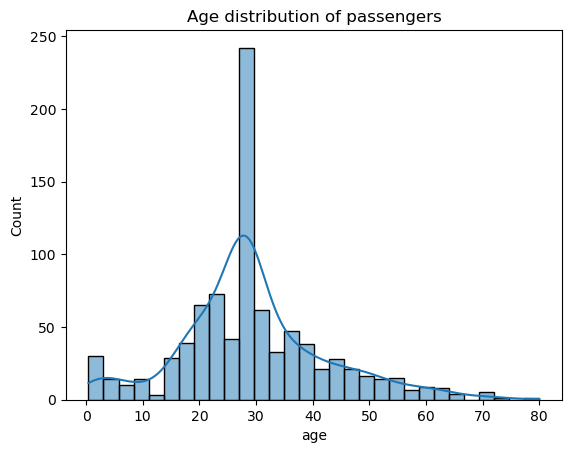

In [10]:
plt.Figure(figsize=(8,4))
sns.histplot(df['age'],bins=30,kde=True)
plt.title("Age distribution of passengers")
plt.savefig('images/age_distribution.png', bbox_inches='tight')
plt.show()

#### Chart 5 — Age vs Survival

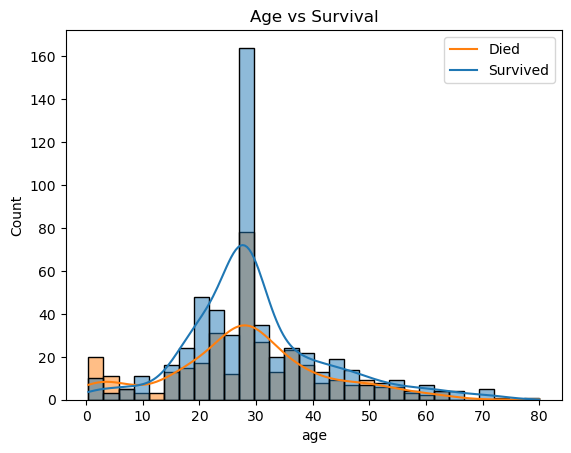

In [11]:
plt.Figure(figsize=(8,4))
sns.histplot(data=df,x='age',hue='survived',bins=30,kde=True)
plt.title("Age vs Survival")
plt.legend(labels=['Died','Survived'])
plt.show()

#### Chart 6 — Fare Distribution

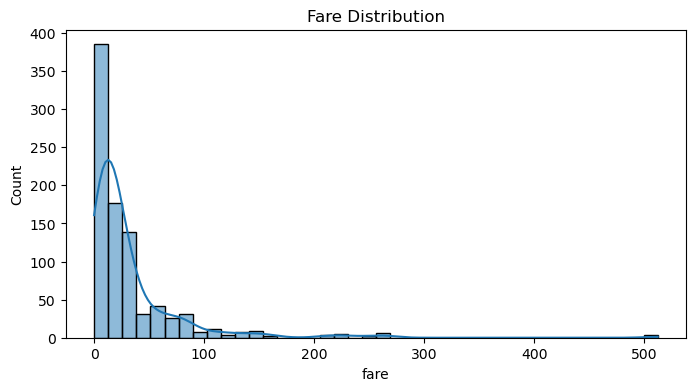

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(data=df['fare'],bins=40,kde=True)
plt.title('Fare Distribution')
plt.savefig('images/fare_distribution.png', bbox_inches='tight')
plt.show()

#### Chart 7 — Correlation Heatmap

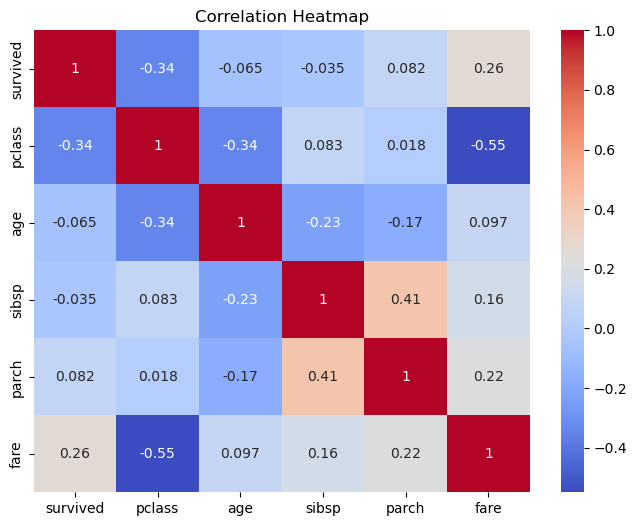

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

#### Chart 8 — Survival by Embarked Port

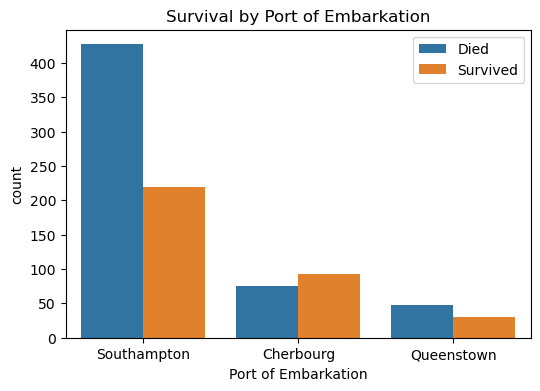

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='embarked', hue= 'survived',data=df)
plt.title('Survival by Port of Embarkation')
plt.legend(labels=['Died','Survived'])
plt.xticks([0,1,2],['Southampton', 'Cherbourg', 'Queenstown'])
plt.xlabel('Port of Embarkation')
plt.savefig('images/survival_by_port.png',bbox_inches='tight')
plt.show()

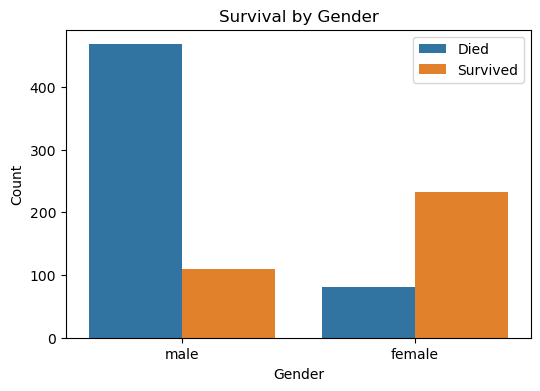

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='survived', data=df)
plt.title('Survival by Gender')
plt.legend(labels=['Died', 'Survived'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Key Findings

In [16]:
print('='*40)
print('KEY FINDINGS')
print('='*40)

print(f'\n1.Overall survival rate : {df['survived'].mean()*100:.1f} %')

gender_survival = df.groupby('sex')['survived'].mean()*100
print(f'\n2. Female survival rate : {gender_survival['female']:.1f}')
print(f'   Male survival rate : {gender_survival['male']:.1f}')

class_survival = df.groupby('pclass')['survived'].mean()*100
print('\n')
print(f'3. 1st class survival : {class_survival[1]:.1f} %')
print(f'   2nd class survival : {class_survival[2]:.1f} %')
print(f'   3rd class survival : {class_survival[3]:.1f} %')

children=df[df['age']<10]['survived'].mean() * 100
print(f'\n4. Children (under 10) survival rate : {children:.1f} %')



KEY FINDINGS

1.Overall survival rate : 38.4 %

2. Female survival rate : 74.2
   Male survival rate : 18.9


3. 1st class survival : 63.0 %
   2nd class survival : 47.3 %
   3rd class survival : 24.2 %

4. Children (under 10) survival rate : 61.3 %


### Simple ML Model


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

#prepare data
df_ml=df.copy()
df_ml['sex']=df_ml['sex'].map({'male':0,'female': 1})
df_ml['embarked']=df_ml['embarked'].map({'S':0,'C':1,'Q':2})

# Feature and target
x = df_ml[['pclass','sex','age','sibsp','parch','fare']]
y=df_ml['survived']

#split 
x_train, x_test, y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

#train
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

#evaluate
predictions = model.predict(x_test)
accuracy = accuracy_score(y_test,predictions)
print(f"Model Accuracy : {accuracy*100:.2f}%")
print("\nDetailed Report : ")
print(classification_report(y_test,predictions))


Model Accuracy : 80.45%

Detailed Report : 
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



#### Feature Importance

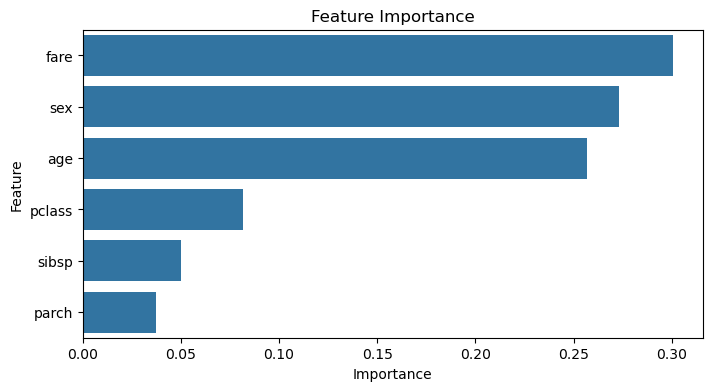

  Feature  Importance
5    fare    0.300568
1     sex    0.273294
2     age    0.256716
0  pclass    0.081660
3   sibsp    0.050145
4   parch    0.037616


In [18]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.savefig('images/feature_importance.png', bbox_inches='tight')
plt.show()

print(feature_importance)

In [ ]:
def predict_survival():
    print("=" * 45)
    print("  TITANIC SURVIVAL PREDICTOR")
    print("=" * 45)
    print("Enter passenger details below:\n")

    # --- GET INPUTS ---

    # Passenger Class
    while True:
        try:
            pclass = int(input("Passenger Class (1=First, 2=Second, 3=Third): "))
            if pclass in [1, 2, 3]:
                break
            else:
                print("  Please enter 1, 2, or 3")
        except ValueError:
            print("  Please enter a valid number")

    # Gender
    while True:
        sex_input = input("Gender (male/female): ").strip().lower()
        if sex_input in ['male', 'female']:
            sex = 0 if sex_input == 'male' else 1
            break
        else:
            print("  Please enter 'male' or 'female'")

    # Age
    while True:
        try:
            age = float(input("Age (e.g. 25): "))
            if 0 < age < 120:
                break
            else:
                print("  Please enter a valid age between 0 and 120")
        except ValueError:
            print("  Please enter a valid number")

    # Siblings / Spouses
    while True:
        try:
            sibsp = int(input("Number of Siblings/Spouses aboard (0,1,2...): "))
            if sibsp >= 0:
                break
            else:
                print("  Please enter 0 or more")
        except ValueError:
            print("  Please enter a valid number")

    # Parents / Children
    while True:
        try:
            parch = int(input("Number of Parents/Children aboard (0,1,2...): "))
            if parch >= 0:
                break
            else:
                print("  Please enter 0 or more")
        except ValueError:
            print("  Please enter a valid number")

    # Fare
    while True:
        try:
            fare = float(input("Fare Paid (e.g. 7.25 for 3rd class, 71.0 for 1st class): "))
            if fare >= 0:
                break
            else:
                print("  Please enter a valid fare amount")
        except ValueError:
            print("  Please enter a valid number")

    # --- MAKE PREDICTION ---

    # Build input array in same format model was trained on
    passenger = pd.DataFrame({
        'pclass': [pclass],
        'sex':    [sex],
        'age':    [age],
        'sibsp':  [sibsp],
        'parch':  [parch],
        'fare':   [fare]
    })

    # Get prediction (0 or 1)
    prediction = model.predict(passenger)[0]

    # Get probability (confidence)
    probability = model.predict_proba(passenger)[0]
    survive_chance  = probability[1] * 100   # chance of surviving
    die_chance      = probability[0] * 100   # chance of dying

    # --- DISPLAY RESULT ---

    print("\n" + "=" * 45)
    print("  PASSENGER SUMMARY")
    print("=" * 45)

    class_names = {1: "1st Class", 2: "2nd Class", 3: "3rd Class"}
    print(f"  Class:              {class_names[pclass]}")
    print(f"  Gender:             {sex_input.capitalize()}")
    print(f"  Age:                {age}")
    print(f"  Siblings/Spouses:   {sibsp}")
    print(f"  Parents/Children:   {parch}")
    print(f"  Fare Paid:          £{fare:.2f}")

    print("\n" + "=" * 45)
    print("  PREDICTION RESULT")
    print("=" * 45)

    if prediction == 1:
        print(f"\n  ✓ This passenger would SURVIVE")
        print(f"\n  Survival chance:  {survive_chance:.1f}%")
        print(f"  Death chance:     {die_chance:.1f}%")
    else:
        print(f"\n  ✗ This passenger would NOT SURVIVE")
        print(f"\n  Death chance:     {die_chance:.1f}%")
        print(f"  Survival chance:  {survive_chance:.1f}%")

    # Confidence level description
    confidence = max(survive_chance, die_chance)
    if confidence >= 80:
        conf_label = "Very High Confidence"
    elif confidence >= 65:
        conf_label = "High Confidence"
    elif confidence >= 55:
        conf_label = "Moderate Confidence"
    else:
        conf_label = "Low Confidence (borderline case)"

    print(f"\n  Model confidence: {conf_label} ({confidence:.1f}%)")
    print("=" * 45)

    return prediction, survive_chance


# Run the predictor
predict_survival()

  TITANIC SURVIVAL PREDICTOR
Enter passenger details below:

